# Assignment 6: Neural Network Showdown

Build and compare neural network architectures on image and time-series data.

## Setup

In [2]:
%pip install -q -r requirements.txt

# GPU acceleration (platform-specific)
import platform
if platform.system() == "Darwin" and platform.machine() == "arm64":
    %pip install -q tensorflow-metal

%reset -f


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import numpy as np
import pandas as pd

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

from tensorflow import keras
from keras import Sequential
from keras.layers import (
    Dense, Flatten, Dropout, Conv2D, MaxPooling2D, LSTM, Input
)
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix

from helpers import (
    load_cifar10, load_ecg5000,
    plot_training_history, plot_confusion_matrix,
    plot_sample_images, plot_ecg_traces, plot_predictions,
    CIFAR10_CLASSES, ECG_CLASSES,
)

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete!")

No GPU detected — using CPU
Setup complete!


---

## Part 1: Dense Baseline on CIFAR-10

**Task:** Build a Dense (fully connected) network to classify CIFAR-10 images.

CIFAR-10 has 60,000 color images (32x32x3) across 10 classes. A Dense network
flattens each image into 3,072 numbers and classifies from there. This is our
baseline — it ignores spatial structure entirely.

**Architecture requirements:**
- Flatten the input
- At least 2 hidden Dense layers with ReLU activation
- Dropout after each hidden layer
- Output: Dense(10, softmax)

In [4]:
print("Part 1: Dense Baseline on CIFAR-10")
print("-" * 40)

# Load data (normalized to [0,1], one-hot encoded)
X_train, y_train, X_test, y_test = load_cifar10()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Part 1: Dense Baseline on CIFAR-10
----------------------------------------


/home/codespace/.local/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


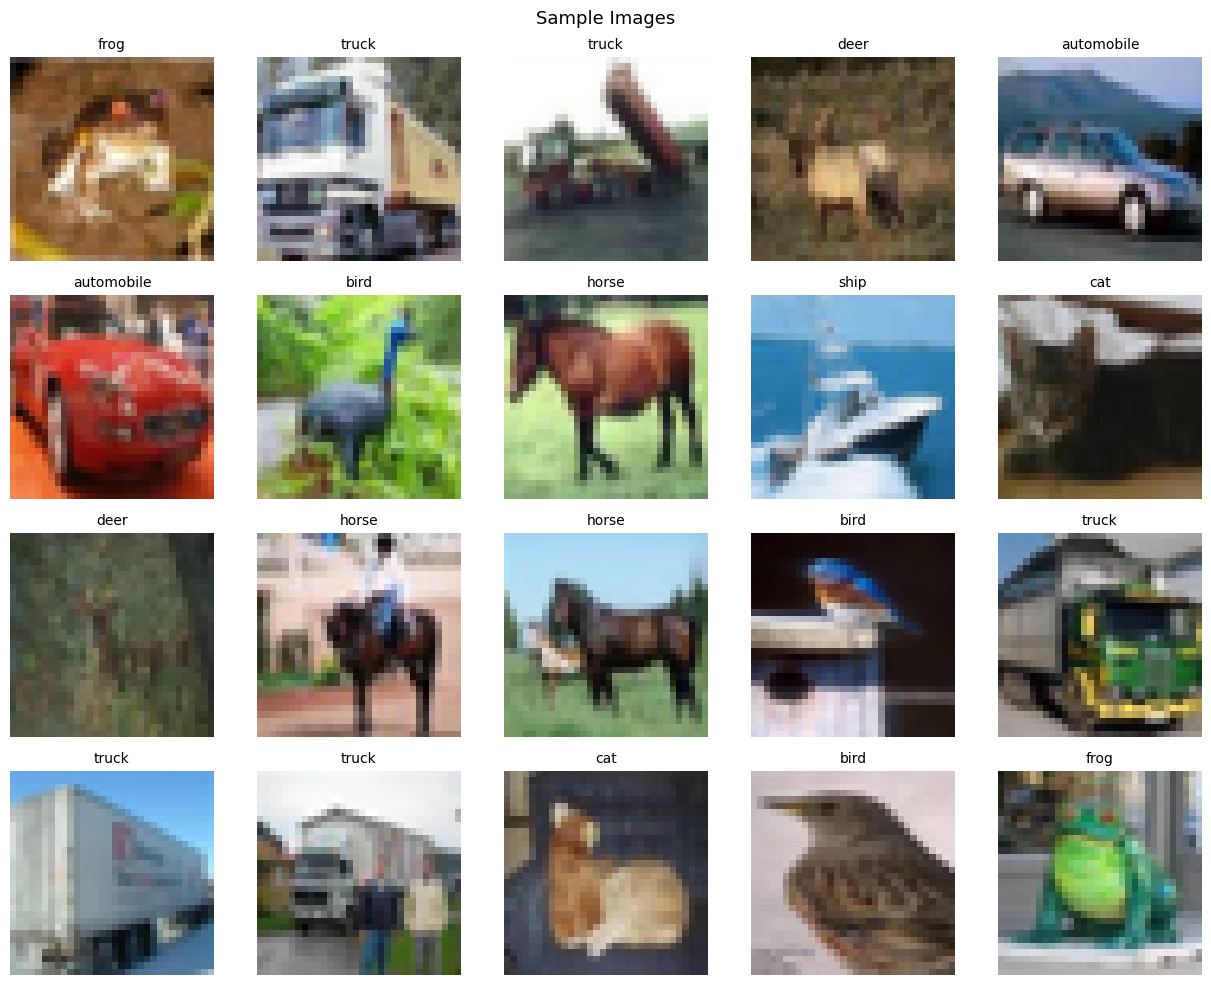

In [5]:
# Visualize some training images to verify data loaded correctly
plot_sample_images(X_train, y_train, CIFAR10_CLASSES)

In [6]:
# TODO: Build a Dense model using Sequential
# Tip: call model_dense.summary() after building to verify your architecture
# Requirements:
#   - Input(shape=(32, 32, 3))
#   - Flatten()
#   - At least 2 Dense hidden layers with activation='relu'
#   - Dropout after each hidden Dense layer
#   - Dense(10, activation='softmax') as output
model_dense = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax') 
])  
model_dense.summary()
# replace with your Sequential model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# TODO: Compile the model
model_dense.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
# TODO: Train with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3,restore_best_weights=True)
history_dense = model_dense.fit(X_train, y_train,epochs=20, batch_size=128,validation_split=0.1,callbacks=[early_stop])


Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.2288 - loss: 2.0743 - val_accuracy: 0.3340 - val_loss: 1.8545
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2851 - loss: 1.9356 - val_accuracy: 0.3556 - val_loss: 1.8250
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2953 - loss: 1.9071 - val_accuracy: 0.3620 - val_loss: 1.7956
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3104 - loss: 1.8739 - val_accuracy: 0.3652 - val_loss: 1.8057
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3199 - loss: 1.8589 - val_accuracy: 0.3758 - val_loss: 1.7945
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3220 - loss: 1.8484 - val_accuracy: 0.3636 - val_loss: 1.7963
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3255 - loss: 1.8395 - val_accuracy: 0.3754 - val_loss: 1.7858
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3325 - loss: 1.8294 - val_accu

In [9]:
# TODO: Evaluate on test set
test_loss, test_acc = model_dense.evaluate(X_test, y_test, verbose=0)

# TODO: Generate predictions and confusion matrix
y_pred = np.argmax(model_dense.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

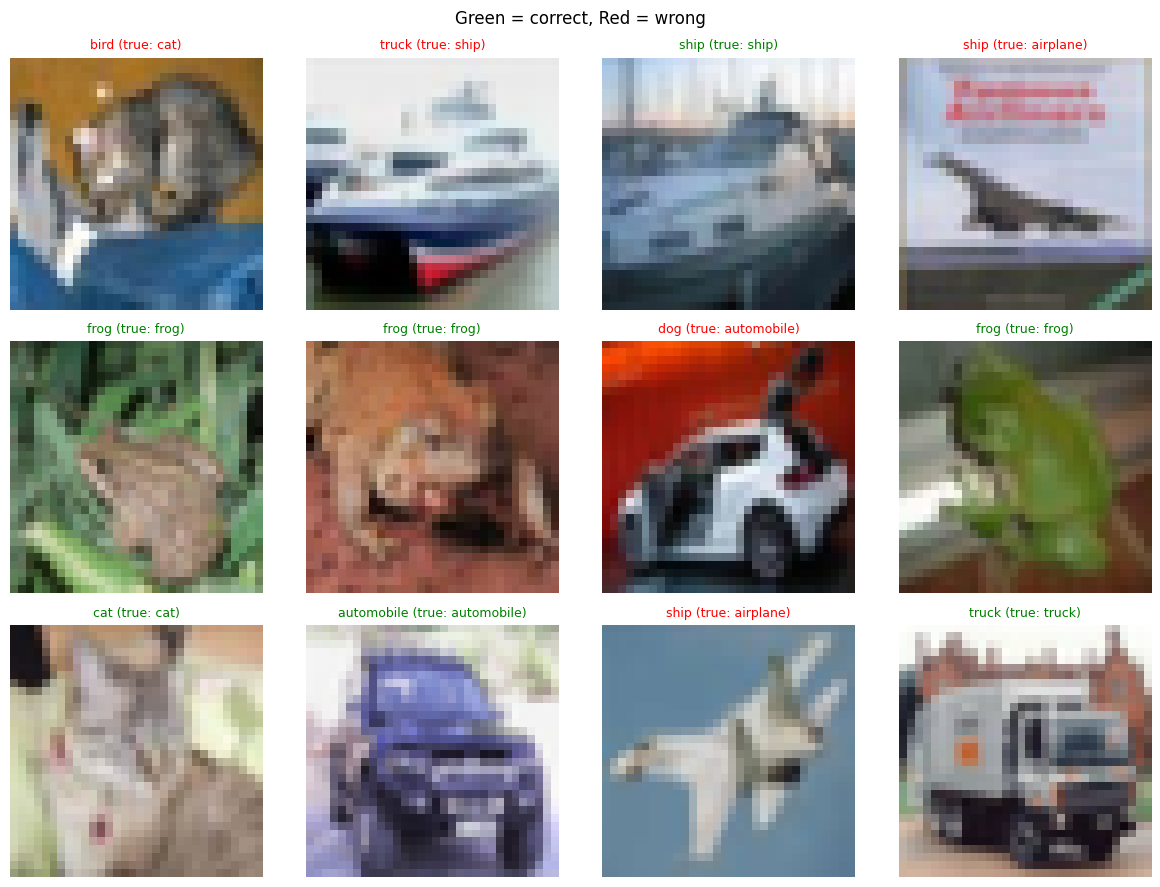

In [10]:
# Optional: visualize predictions and confusion matrix to diagnose issues
plot_predictions(X_test, y_true, y_pred, CIFAR10_CLASSES)
plot_confusion_matrix(y_true, y_pred, list(CIFAR10_CLASSES.values()),os.path.join(OUTPUT_DIR, "part1_confusion_matrix.png"))

In [11]:
# Save results (do not modify this cell)
results = {
    "accuracy": float(test_acc),
    "confusion_matrix": cm.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part1_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Dense accuracy: {test_acc:.4f}")
print("Saved output/part1_results.json")

Dense accuracy: 0.4104
Saved output/part1_results.json


---

## Part 2: CNN on CIFAR-10

**Task:** Build a CNN to classify the same CIFAR-10 images. Compare its accuracy
to the Dense baseline from Part 1.

CNNs use convolutional filters that slide across the image, detecting local
patterns (edges, textures, shapes). This preserves spatial structure that
Dense layers discard.

**Architecture requirements:**
- At least 2 Conv2D + MaxPooling2D blocks
- Flatten, then Dense hidden layer with Dropout
- Output: Dense(10, softmax)

In [12]:
print("\nPart 2: CNN on CIFAR-10")
print("-" * 40)

# Data is already loaded from Part 1 (X_train, y_train, X_test, y_test)


Part 2: CNN on CIFAR-10
----------------------------------------


In [13]:
# TODO: Build a CNN model using Sequential
# Requirements:
#   - Input(shape=(32, 32, 3))
#   - At least 2 blocks of: Conv2D(filters, (3,3), activation='relu')
#                            + MaxPooling2D((2,2))
#   - Flatten()
#   - Dense hidden layer with ReLU + Dropout
#   - Dense(10, activation='softmax') as output
# Tip: call model_cnn.summary() after building to check layer shapes and param counts
model_cnn = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation = 'relu'),
    Dropout(0.3),
    Dense(10, activation='softmax') 
])  # replace with your Sequential model

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 924,106 (3.53 MB)

 Trainable params: 924,106 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# TODO: Compile the model
model_cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
# TODO: Train with EarlyStopping and ModelCheckpoint
callbacks = [EarlyStopping(monitor='val_loss', patience=3,restore_best_weights=True),ModelCheckpoint('output/best_cnn.keras',save_best_only=True, monitor='val_accuracy'),]
history_cnn = model_cnn.fit(X_train, y_train,epochs=15, batch_size=64,validation_split=0.1,callbacks=callbacks)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.3283 - loss: 1.7967 - val_accuracy: 0.4754 - val_loss: 1.4808
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.4377 - loss: 1.5246 - val_accuracy: 0.5348 - val_loss: 1.3228
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.4701 - loss: 1.4274 - val_accuracy: 0.5582 - val_loss: 1.2806
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.4981 - loss: 1.3630 - val_accuracy: 0.5846 - val_loss: 1.1972
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5111 - loss: 1.3181 - val_accuracy: 0.5858 - val_loss: 1.1737
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.5272 - loss: 1.2840 - val_accuracy: 0.6022 - val_loss: 1.1476
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.5433 - loss: 1.2415 - val_accuracy: 0.6100 - val_loss: 1.1197
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5528 - loss: 1.2101 - 

In [16]:
# TODO: Plot training history
plot_training_history(history_cnn,os.path.join(OUTPUT_DIR, "part2_training_history.png"))

In [17]:
# TODO: Evaluate on test set
cnn_loss, cnn_acc = model_cnn.evaluate(X_test, y_test, verbose=0)

# TODO: Generate predictions and confusion matrix
y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_true_cnn = np.argmax(y_test, axis=1)
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

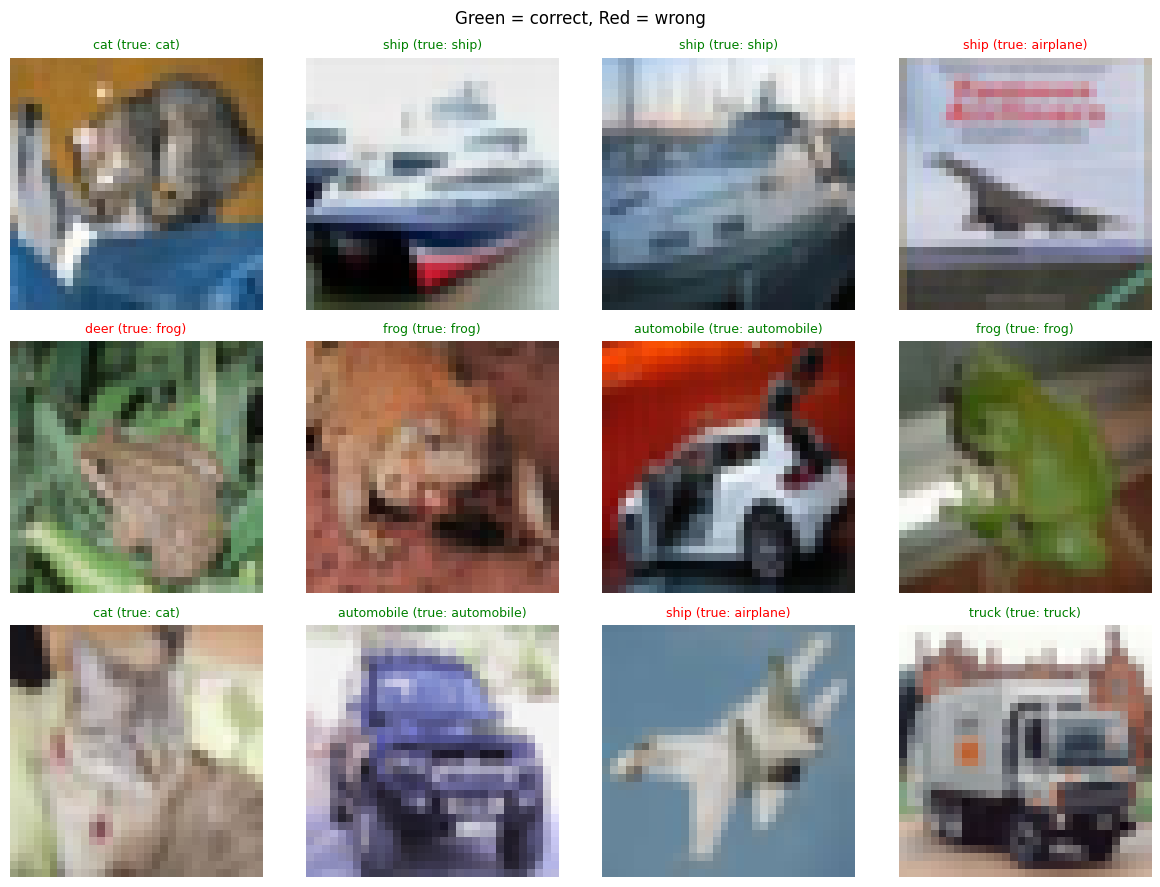

In [18]:
# Optional: visualize predictions and confusion matrix to diagnose issues
plot_predictions(X_test, y_true_cnn, y_pred_cnn, CIFAR10_CLASSES)
plot_confusion_matrix(y_true_cnn, y_pred_cnn, list(CIFAR10_CLASSES.values()),os.path.join(OUTPUT_DIR, "part2_confusion_matrix.png"))

In [19]:
# Save results (do not modify this cell)
results_cnn = {
    "accuracy": float(cnn_acc),
    "confusion_matrix": cm_cnn.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part2_results.json"), "w") as f:
    json.dump(results_cnn, f, indent=2)

comparison = pd.DataFrame([
    {"model": "Dense", "accuracy": float(test_acc)},
    {"model": "CNN", "accuracy": float(cnn_acc)},
])
comparison.to_csv(os.path.join(OUTPUT_DIR, "part2_comparison.csv"), index=False)

print(f"CNN accuracy:   {cnn_acc:.4f}")
print(f"Dense accuracy: {test_acc:.4f}")
print(f"Improvement:    {cnn_acc - test_acc:+.4f}")
print("Saved output/part2_results.json and output/part2_comparison.csv")

CNN accuracy:   0.6085
Dense accuracy: 0.4104
Improvement:    +0.1981
Saved output/part2_results.json and output/part2_comparison.csv


---

## Part 3: LSTM on ECG5000

**Task:** Build an LSTM to classify heartbeat recordings.

ECG5000 contains 5,000 heartbeat recordings — each is 140 time steps of voltage
measurements, classified into 5 types (Normal, Supraventricular, Premature
Ventricular, Fusion, Unknown). This is sequential data where order matters,
making it a natural fit for recurrent networks.

**Architecture requirements:**
- LSTM layer (any reasonable number of units)
- Dropout for regularization
- Dense output with softmax (5 classes)

In [20]:
print("\nPart 3: LSTM on ECG5000")
print("-" * 40)

# Load ECG data (already shaped for RNN input)
X_train_ecg, y_train_ecg, X_test_ecg, y_test_ecg = load_ecg5000()
print(f"Train: {X_train_ecg.shape}, Test: {X_test_ecg.shape}")
print(f"Classes: {list(ECG_CLASSES.values())}")


Part 3: LSTM on ECG5000
----------------------------------------
Train: (4000, 140, 1), Test: (1000, 140, 1)
Classes: ['Normal', 'Supraventricular', 'Premature Ventricular', 'Fusion', 'Unknown']


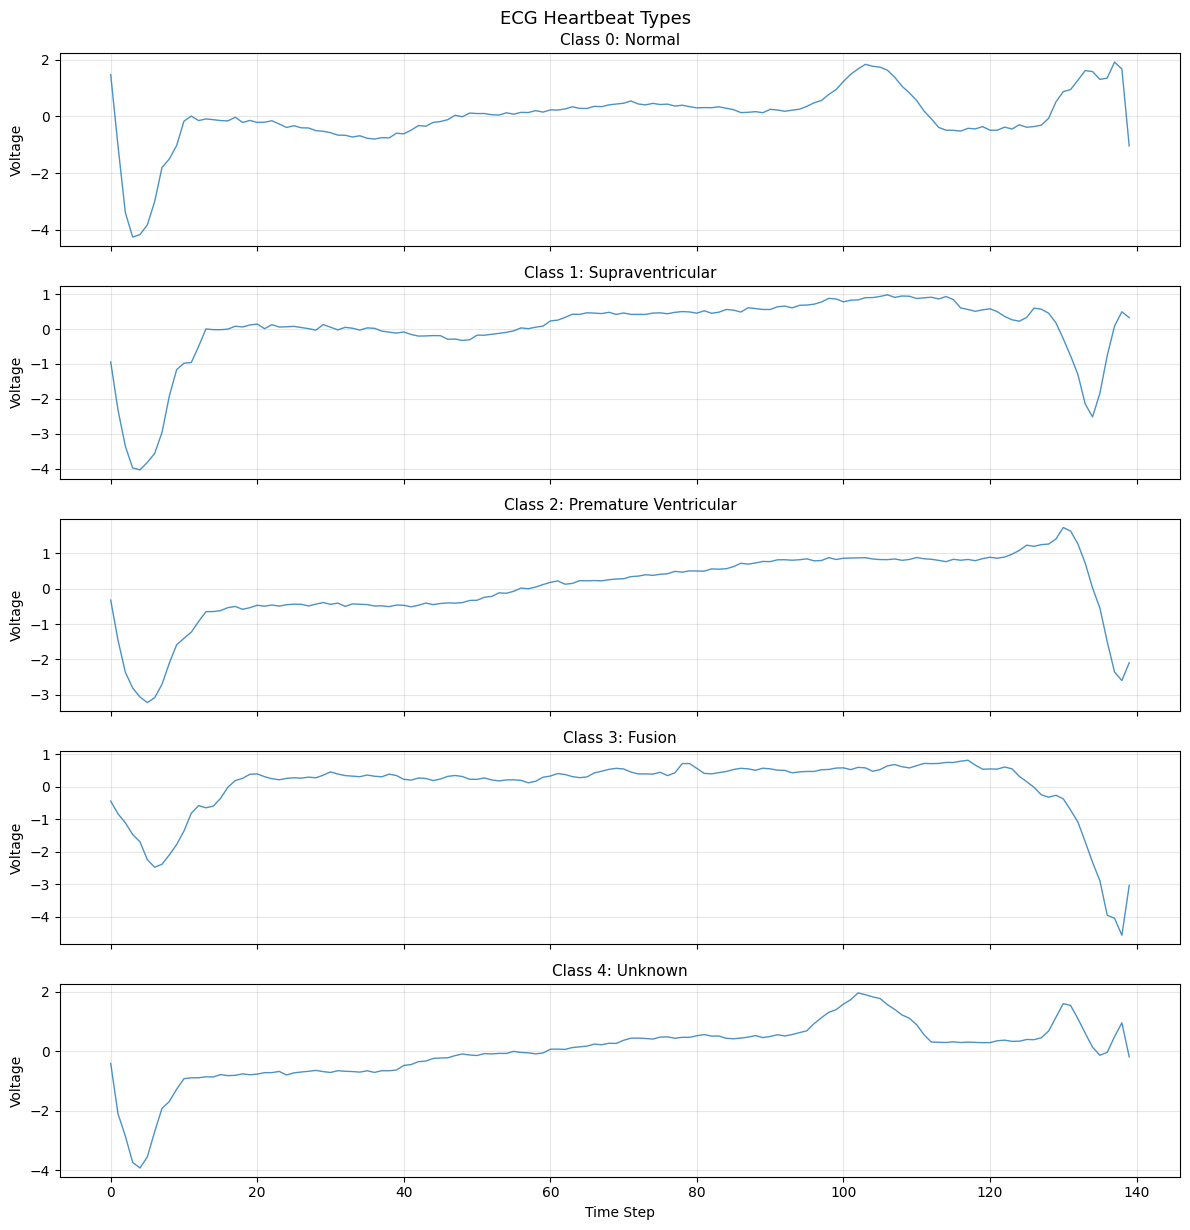

In [21]:
# Visualize ECG traces to understand the data
plot_ecg_traces(X_train_ecg, y_train_ecg, ECG_CLASSES)

In [22]:
# TODO: Build an LSTM model using Sequential
# Requirements:
#   - Input(shape=(140, 1))
#   - LSTM layer (e.g., 64 units)
#   - Dropout
#   - Dense(5, activation='softmax')
# Tip: call model_lstm.summary() after building to verify your architecture
model_lstm = Sequential([
    Input(shape=(140, 1)),
    LSTM(64),
    Dropout(0.3),
    Dense(5, activation='softmax') 
]) # replace with your Sequential model

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,221 (67.27 KB)

 Trainable params: 17,221 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# TODO: Compile the model
model_lstm.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
# TODO: Train with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)
history_lstm = model_lstm.fit(X_train_ecg, y_train_ecg,epochs=30, batch_size=32,validation_split=0.1,callbacks=[early_stop])

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8778 - loss: 0.5586 - val_accuracy: 0.8925 - val_loss: 0.3756
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9247 - loss: 0.2841 - val_accuracy: 0.9025 - val_loss: 0.3377
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9367 - loss: 0.2369 - val_accuracy: 0.9200 - val_loss: 0.3134
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9397 - loss: 0.2325 - val_accuracy: 0.9175 - val_loss: 0.3120
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9428 - loss: 0.2204 - val_accuracy: 0.9175 - val_loss: 0.3005
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9433 - loss: 0.2103 - val_accuracy: 0.9200 - val_loss: 0.2880
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9444 - loss: 0.2111 - val_accuracy: 0.9100 - val_loss: 0.3037
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9442 - loss: 0.2020 - val_accu

In [25]:
# TODO: Plot training history
plot_training_history(history_lstm,os.path.join(OUTPUT_DIR, "part3_training_history.png"))

In [26]:
# TODO: Evaluate on test set
lstm_loss, lstm_acc = model_lstm.evaluate(X_test_ecg, y_test_ecg, verbose=0)

# TODO: Generate predictions and confusion matrix
y_pred_ecg = np.argmax(model_lstm.predict(X_test_ecg, verbose=0), axis=1)
y_true_ecg = np.argmax(y_test_ecg, axis=1)
cm_ecg = confusion_matrix(y_true_ecg, y_pred_ecg)

In [27]:
# Optional: visualize confusion matrix to see which heartbeat types are confused
plot_confusion_matrix(y_true_ecg, y_pred_ecg, list(ECG_CLASSES.values()),os.path.join(OUTPUT_DIR, "part3_confusion_matrix.png"))

In [28]:
# Save results (do not modify this cell)
results_ecg = {
    "accuracy": float(lstm_acc),
    "confusion_matrix": cm_ecg.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part3_results.json"), "w") as f:
    json.dump(results_ecg, f, indent=2)

print(f"LSTM accuracy: {lstm_acc:.4f}")
print("Saved output/part3_results.json")

LSTM accuracy: 0.9290
Saved output/part3_results.json


---

## Validation

In [29]:
print("\nAll parts complete!")
print("Run 'pytest .github/tests/ -v' in your terminal to check your work.")


All parts complete!
Run 'pytest .github/tests/ -v' in your terminal to check your work.
